<a href="https://colab.research.google.com/github/alfagalileo/Metodos_Computacionales_1/blob/main/_Clase5.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab">
</a>

In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [3]:
x, a, b  = sp.symbols(["x", "a", "b"])
xj = [a,b]

def lagrange(x, i, xj):
    _n = len(xj)

    L = 1
    for j in range(_n):
        if j != i:
            L *= (x-xj[j])/(xj[i] - xj[j])

    return sp.simplify(L)


In [4]:
L0 = lagrange(x, 0, xj)
L1 = lagrange(x, 1, xj)

w0 = sp.integrate(L0, (x, a, b))
w1 = sp.integrate(L1, (x, a, b))

sp.pprint(sp.simplify(w0))
sp.pprint(sp.simplify(w1))


  a   b
- ─ + ─
  2   2
  a   b
- ─ + ─
  2   2


## Regla del trapecio

$$
    \begin{eqnarray}
        \int_a^b f(x)dx &\approx f(a)\int_a^b L_0 (x) dx + f(a)\int_a^b L_1 (x) dx \\
        & \approx f(a) \left[ \frac{b-a}{2} \right] + f(b) \left[ \frac{b-a}{2} \right] \\
        & \approx \frac{h}{2} \left[ f(a) + f(b)\right]
    \end{eqnarray}
$$

Si tomamos mas trapecios con vértices  en $x_0$, $x_0+h$, $x_0+2h$, $⋯$

$$
    \begin{align*}
    \int _{a}^{b} f( x) dx & \approx \frac{h}{2}\left[ f( a) +2\sum _{j=1}^{n-1} f( x_{j}) +f( b)\right]
    \end{align*}
$$

In [5]:
xj = [a, (a+b)/2, b]

L0 = lagrange(x, 0, xj)
L1 = lagrange(x, 1, xj)
L2 = lagrange(x, 2, xj)

w0 = sp.integrate(L0, (x, a, b))
w1 = sp.integrate(L1, (x, a, b))
w2 = sp.integrate(L2, (x, a, b))

sp.pprint(sp.simplify(w0))
sp.pprint(sp.simplify(w1))
sp.pprint(sp.simplify(w2))

  a   b
- ─ + ─
  6   6
  2⋅a   2⋅b
- ─── + ───
   3     3 
  a   b
- ─ + ─
  6   6


## Regla de simpson

$$
    \begin{eqnarray}
        \int_a^b f(x)dx &\approx f(a)\int_a^b L_0 (x) dx + f\left(\frac{a+b}{2}\right)\int_a^b L_1 (x) dx + f(b)\int_a^b L_2 (x) dx\\
        & \approx f(a) \left[ \frac{b-a}{6} \right] + f\left(\frac{a+b}{2}\right) \left[ \frac{2(b-a)}{3} \right] + f(b) \left[ \frac{b-a}{6} \right]\\
        & \approx \frac{h}{3}f(a) +  \frac{4}{3} f\left(\frac{a+b}{2}\right) + \frac{h}{3}f(b) \\
        & \approx \frac{h}{3}\left[ f(a) + 4 f\left(\frac{a+b}{2}\right) + f(b)\right]
    \end{eqnarray}
$$

Tomando $n$ particiones entre $a$ y $b$,

$$
    \begin{align*}
    \int _{a}^{b} f( x) dx & \approx \frac{h}{3}\left[ f( a) +2\sum_{j=1}^{n/ 2-1} f( x_{2j}) +4\sum _{j=1}^{n/2} f( x_{2j-1}) +f( b)\right]
    \end{align*}
$$

In [6]:
def trapz(f, a, b, n):
    xn = np.linspace(a,b,n)
    fn = f(xn)
    h = xn[1] - xn[0]
    return 0.5*h*( fn[0] + 2*fn[1:-1].sum() + fn[-1])

def simpson(f, a, b, n):
    if n % 2 != 0: raise ValueError("n debe ser par")
    xn = np.linspace(a, b, n + 1)
    fn = f(xn)
    h = (b - a)/n
    return h/3*( fn[0] + 4 * fn[1:-1:2].sum() + 2 * fn[2:-1:2].sum() + fn[-1] )

In [7]:
trapz( np.sin, 0, np.pi, 60 )

np.float64(1.9995274312545632)

In [8]:
simpson( np.sin, 0, np.pi, 114 )

np.float64(2.0000000064088015)

**Ejemplo**: Cálculo del periodo de oscilación de un péndulo de amplitud grande


$$
    T= 4\sqrt{\frac{L}{g}} \int_0^{\pi/2} \frac{d\theta} {\sqrt{1-k^2\sin^2\theta}},
$$

Donde $k=\sin\left(\frac{\theta_0}{2}\right)$.

para

$$
    L=1\,\mathrm{m}, \qquad \theta_0=60^\circ,
$$

calcule $T$ utilizando _Simpson_. Después compare con la aproximación de pequeñas oscilaciones:

$$
    T_0=2\pi\sqrt{\frac{L}{g}}.
$$


In [11]:
L = 1 #m
g = 9.8 #m/s^2
θ0 = 10
k = np.sin(np.deg2rad(θ0)/2)

T_analitic = 4*np.sqrt(L/g)*simpson( lambda th: 1/np.sqrt(1- k**2*np.sin(th)**2), 0, np.pi/2, 30 )
T_approx = 2*np.pi*np.sqrt(L/g)

In [12]:
print( f"El error procentual es: {((T_analitic - T_approx)/T_analitic*100):.2} %" )

El error procentual es: 0.19 %


## Cuadratura Gaussiana

$$
    \int_a^b f(x) dx \approx c_1 f(x_1) + c_2 f(x_2)
$$

El problema ahora consiste en determinar los coeficientes $c_i$ y los puntos de cuadratura $x_i$ al interior del intervalo $[a,b]$ que producen una mejor aproximación a la integral de la función.

Para hallar los valores de las incógnitas, podemos usar el método de coeficientes indeterminados, expandiendo la función $f(x)$ en un polinomio de orden 3: $f(x) = a_0 + a_1 x + a_2 x^2 + a_3 x^3$

$$
    \int_a^b f(x)dx = \int_a^b (a_0 + a_1 x + a_2 x^2 + a_3 x^3)dx
$$

e igualamos

$$
    \int_a^b (a_0 + a_1 x + a_2 x^2 + a_3 x^3)dx = c_1(a_0 + a_1 x_1 + a_2 x_1^2 + a_3 x_1^3) + c_2(a_0 + a_1 x_2 + a_2 x_2^2 + a_3 x_2^3)
$$

In [13]:
A, x, a, b = sp.symbols(['A:4', 'x', 'a', 'b'])
sp.integrate( A[0] + A[1]*x + A[2]*x**2 + A[3]*x**3, (x,a,b))

-A0*a + A0*b - A1*a**2/2 + A1*b**2/2 - A2*a**3/3 + A2*b**3/3 - A3*a**4/4 + A3*b**4/4

Entonces

$$
    \int_a^b (a_0 + a_1 x + a_2 x^2 + a_3 x^3)dx = a_0(b-a) + a_1 \left(\frac{b^2 - a^2}{2}\right) + a_2\left(\frac{b^3 - a^3}{3}\right) + a_3\left(\frac{b^4 - a^4}{4}\right)
$$

igualando las ecuaciones anteriores,

$$
   a_0(b-a) + a_1 \left(\frac{b^2 - a^2}{2}\right) + a_2\left(\frac{b^3 - a^3}{3}\right) + a_3\left(\frac{b^4 - a^4}{4}\right) = c_1(a_0 + a_1 x_1 + a_2 x_1^2 + a_3 x_1^3) + c_2(a_0 + a_1 x_2 + a_2 x_2^2 + a_3 x_2^3)
$$

O factorizando
$$
   a_0(b-a) + a_1 \left(\frac{b^2 - a^2}{2}\right) + a_2\left(\frac{b^3 - a^3}{3}\right) + a_3\left(\frac{b^4 - a^4}{4}\right) = a_0 (c_1 + c_2) + a_1(c_1 x_1 + c_2 x_2 ) + a_2 (c_1 x_1^2 + c_2 x_2^2) + a_3(c_1 x_1^3 + c_2 x_2^3)
$$

Entonces, se debe cumplir que:

$$
    \begin{eqnarray}
        b-a &= c_1 + c_2 \\
        \frac{b^2-a^2}{2} &= c_1 x_1 + c_2 x_2 \\
        \frac{b^3-a^3}{3} &= c_1 x_1^2 + c_2 x_2^2 \\
        \frac{b^4-a^4}{4} &= c_1 x_1^3 + c_2 x_2^3 \\
    \end{eqnarray}
$$

In [14]:
x1, x2 = sp.symbols('x1 x2')
c1, c2 = sp.symbols('c1 c2')

eqs = [
    sp.Eq( c1 + c2,  b - a ),
    sp.Eq( c1*x1 + c2*x2, (b**2 - a**2)/2),
    sp.Eq( c1*x1**2 + c2*x2**2, (b**3 - a**3)/3 ),
    sp.Eq( c1*x1**3 + c2*x2**3, (b**4 - a**4)/4 )
]

In [15]:
sol = sp.solve(eqs)

In [16]:
sol[1]

{c1: -(a - b)/2,
 c2: -(a - b)/2,
 x1: sqrt(3)*a/6 + a/2 - sqrt(3)*b/6 + b/2,
 x2: a/2 + b/2 - sqrt(3)*(a - b)/6}

La cuadratura de Gauss de dos puntos es:

$$
    \int_{a}^b f(x) dx ≈ \left( \frac{b-a}{2} \right)f\left(  \frac{b+a}{2} - \frac{1}{\sqrt{3}}\left( \frac{b-a}{2}\right) \right) + \left( \frac{b-a}{2} \right)f\left( \frac{b+a}{2} + \frac{1}{\sqrt{3}}\left( \frac{b-a}{2}\right)\right)
$$

Donde,
$$
    \begin{eqnarray}
        c_1 &=& \frac{b-a}{2}\\
        c_2 &=& \frac{b-a}{2}\\
        x_1 &=& \frac{b+a}{2} - \frac{1}{\sqrt{3}}\left( \frac{b-a}{2}\right) \\
        x_2 &=& \frac{b+a}{2} + \frac{1}{\sqrt{3}}\left( \frac{b-a}{2}\right) \\
    \end{eqnarray}
$$

**Ejemplo**:

$$
    \int_{0.1}^{1.3} 5x e^{-2x} dx
$$

In [17]:
def Gauss_quad_2pt(f,a,b):
    h = 0.5*(b-a)
    xm = 0.5*(b+a)
    return h*f( xm - 1/np.sqrt(3)*h ) + h*f( xm + 1/np.sqrt(3)*h )

Gauss_quad_2pt( lambda x: 5*x*np.exp(-2*x**2), 0.1, 1.3)

np.float64(1.1774361251986785)

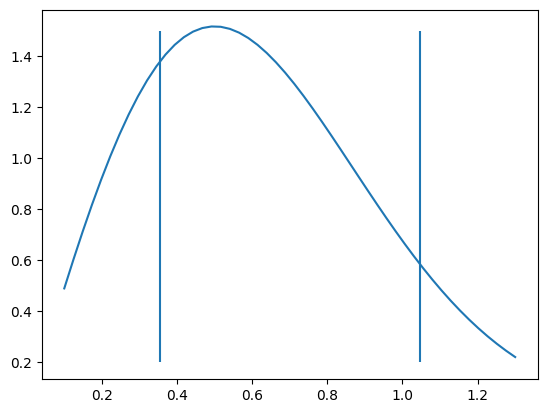

In [18]:
f = lambda x: 5*x*np.exp(-2*x**2)
a, b = 0.1, 1.3
h = 0.5*(b-a)
xm = 0.5*(b+a)
x1 = xm - 1/np.sqrt(3)*h
x2 = xm + 1/np.sqrt(3)*h

x = np.linspace(0.1,1.3)
plt.plot(x,f(x))
plt.vlines([x1],0.2,1.5)
plt.vlines([x2],0.2,1.5)
plt.show()

**Ejercicio**: _Espiral de Cornu_

$$
    C(u) = \int_0^u \cos(\pi t^2/2) dt \qquad  S(u) = \int_0^u \sin(\pi t^2/2) dt
$$

Grafique $C$ vs $S$ de forma paramétrica con $u \in [-5,5]$

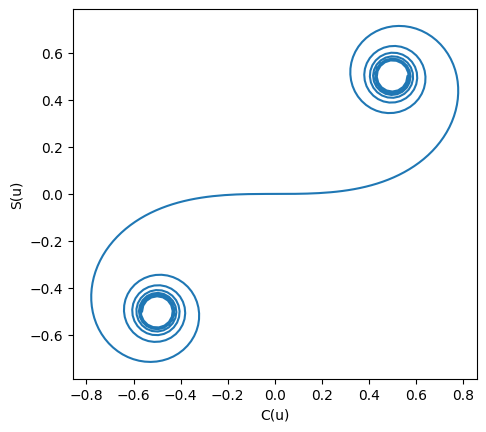

In [19]:
u = np.linspace(-5,5,400)
C = np.array([ simpson(lambda t: np.cos(0.5*np.pi*t**2), 0, ui, 200) for ui in u ])
S = np.array([ simpson(lambda t: np.sin(0.5*np.pi*t**2), 0, ui, 200) for ui in u ])

plt.plot(C, S)
plt.xlabel("C(u)")
plt.ylabel("S(u)")
plt.gca().set_aspect("equal")
plt.show()